<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#1.-막대그래프와-히스토그램" data-toc-modified-id="1.-막대그래프와-히스토그램-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>1. 막대그래프와 히스토그램</a></span></li><li><span><a href="#2.-상자-그림-(Box-Plot)" data-toc-modified-id="2.-상자-그림-(Box-Plot)-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>2. 상자 그림 (Box Plot)</a></span><ul class="toc-item"><li><span><a href="#3.-산점도" data-toc-modified-id="3.-산점도-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>3. 산점도</a></span></li></ul></li><li><span><a href="#4.-상관관계-시각화" data-toc-modified-id="4.-상관관계-시각화-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>4. 상관관계 시각화</a></span></li></ul></div>

### 1. 막대그래프와 히스토그램

In [1]:
# 데이터 가져오기
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

wine_load = load_wine()
wine = pd.DataFrame(wine_load.data, columns=wine_load.feature_names)
wine['Class'] = wine_load.target
wine['Class'] = wine['Class'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

# 도수분포표
wine_type = wine['Class'].value_counts()
wine_type

class_1    71
class_0    59
class_2    48
Name: Class, dtype: int64

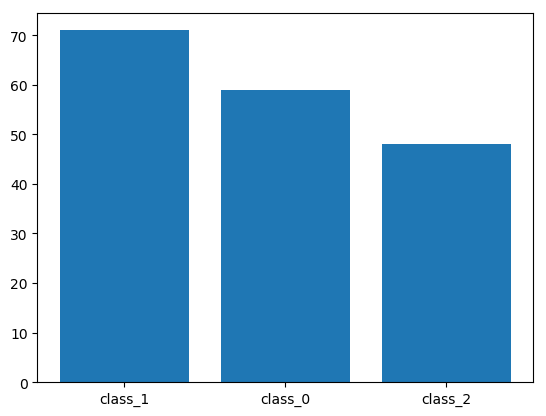

In [2]:
# 막대그래프 그리기
plt.bar(wine_type.index, wine_type.values)
plt.show()

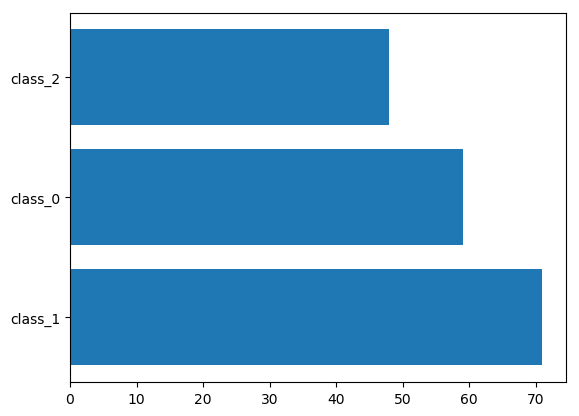

In [3]:
# 수평 막대그래프 그리기
plt.barh(wine_type.index, wine_type.values)
plt.show()

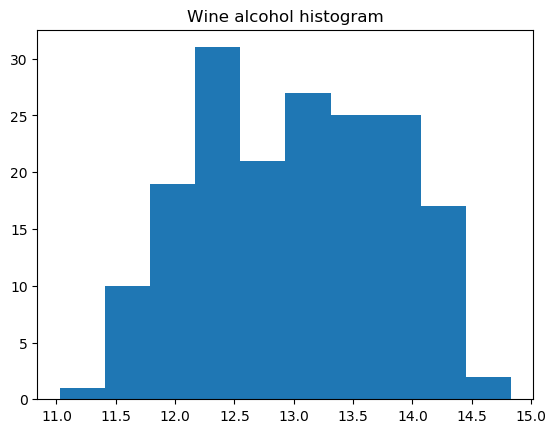

In [4]:
plt.title('Wine alcohol histogram')
plt.hist('alcohol', data=wine)
plt.show()

### 2. 상자 그림 (Box Plot)

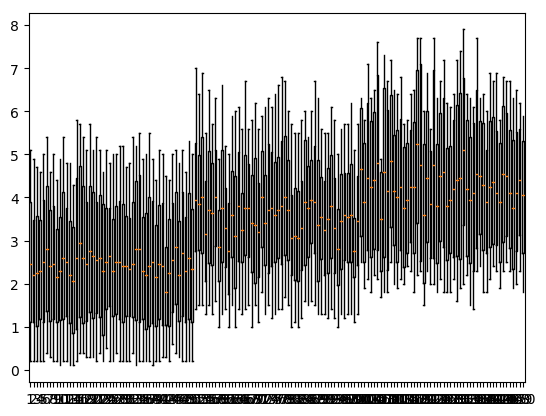

In [5]:
# 데이터 가져오기
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
iris = pd.DataFrame(iris.data, columns=iris.feature_names)
iris['class'] = load_iris().target
iris['class'] = iris['class'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# boxplot 그리기
plt.boxplot(iris.drop(columns='class'))
plt.show()

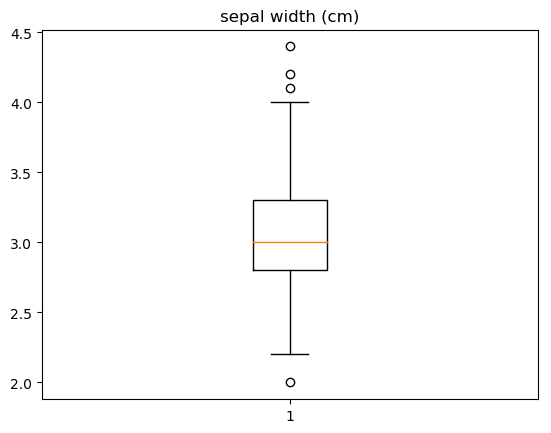

In [6]:
plt.boxplot(iris['sepal width (cm)'], whis=1.5)
plt.title('sepal width (cm)')
plt.show()

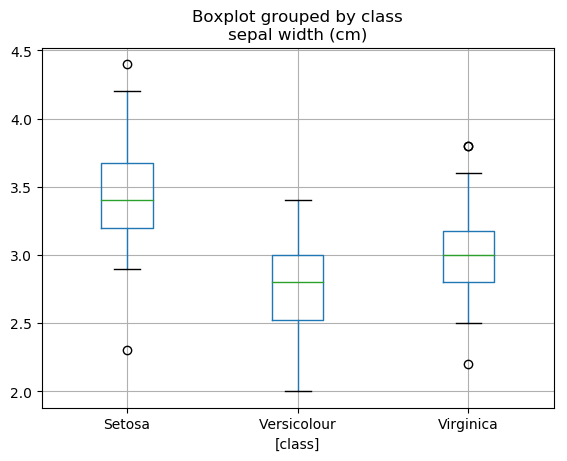

In [7]:
iris[['sepal width (cm)', 'class']].boxplot(by='class')
plt.show()

#### 3. 산점도

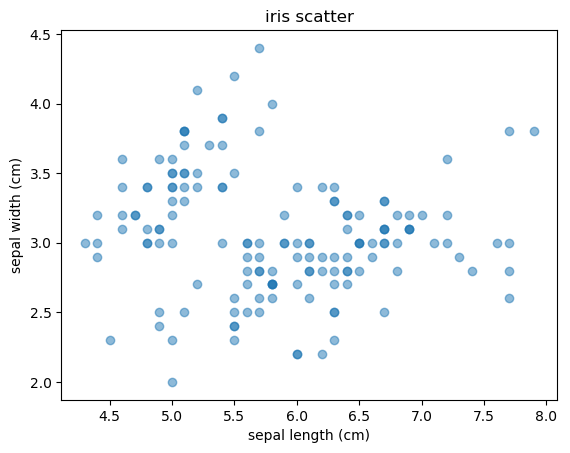

In [8]:
# 데이터 가져오기
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
iris = pd.DataFrame(iris.data, columns=iris.feature_names)
iris['class'] = load_iris().target
iris['class'] = iris['class'].map({0: 'Setosa', 1: 'Versicolour', 2: 'Virginica'})

# 산점도 그리기
plt.title('iris scatter')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.scatter(x=iris['sepal length (cm)'], y=iris['sepal width (cm)'], alpha=0.5)
plt.show()

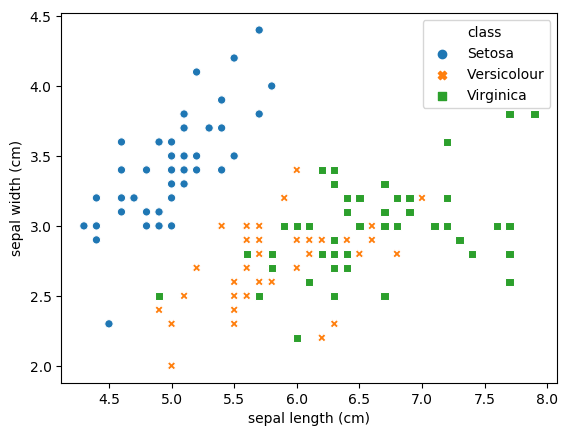

In [9]:
import seaborn as sns

sns.scatterplot(
    x='sepal length (cm)', y='sepal width (cm)',
    data=iris, hue='class', style='class'
)
plt.show()

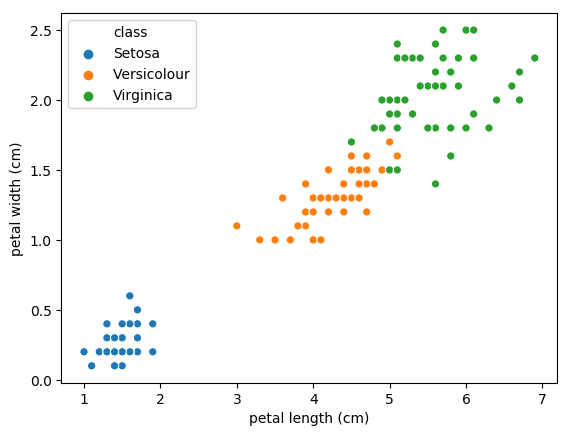

In [10]:
sns.scatterplot(
    x='petal length (cm)', y='petal width (cm)',
    data=iris, hue='class'
)
plt.show()

### 4. 상관관계 시각화

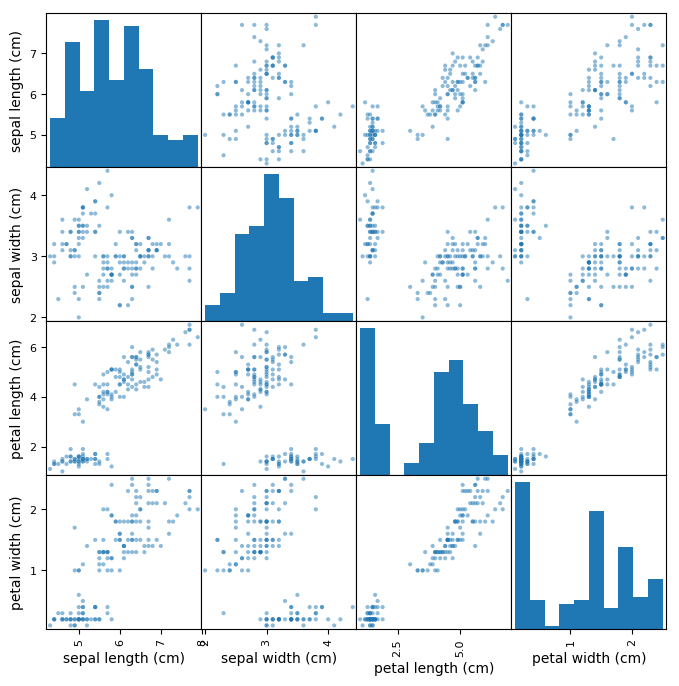

In [11]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# 산점도 행렬
scatter_matrix(iris, alpha=0.5, figsize=(8, 8), diagonal='hist')
plt.show()

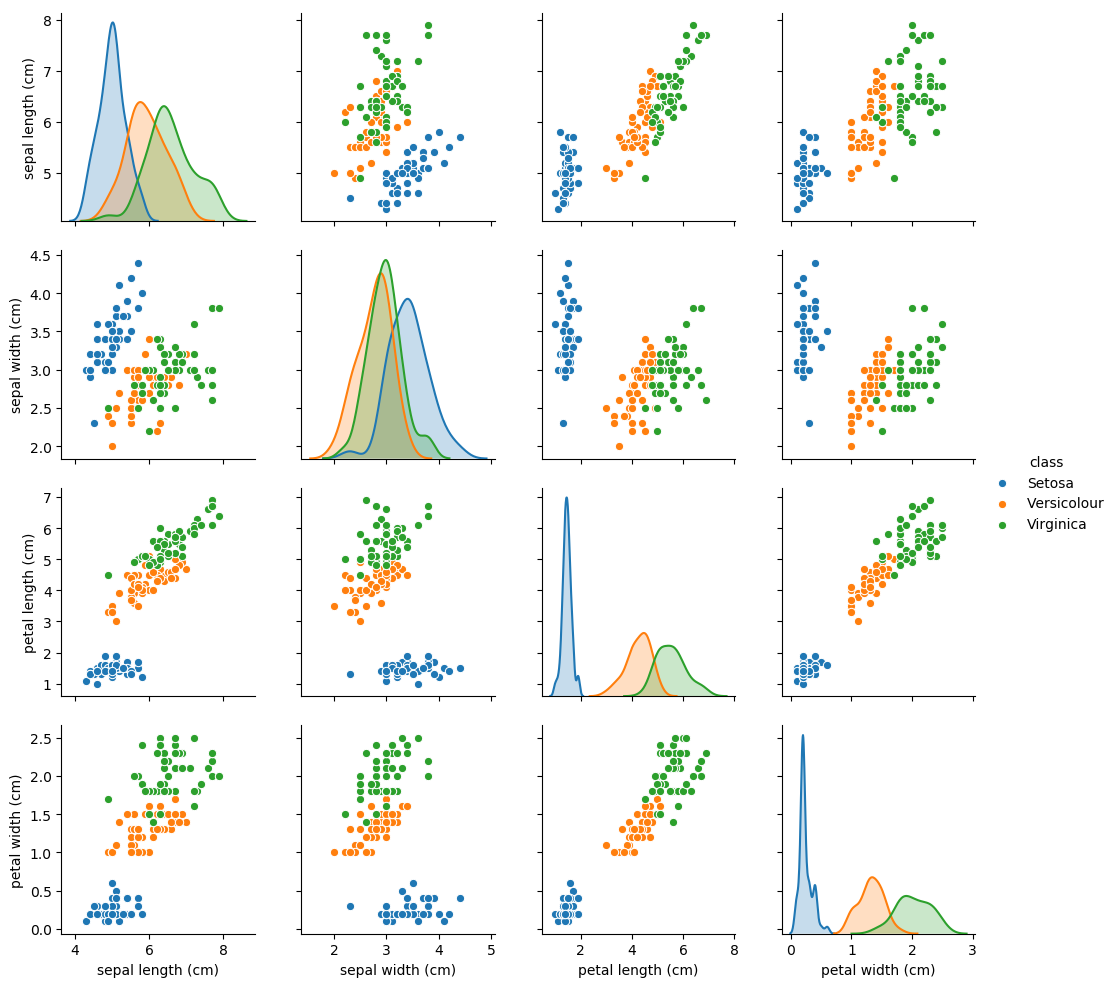

In [12]:
import seaborn as sns
sns.pairplot(iris, diag_kind='auto', hue='class')
plt.show()

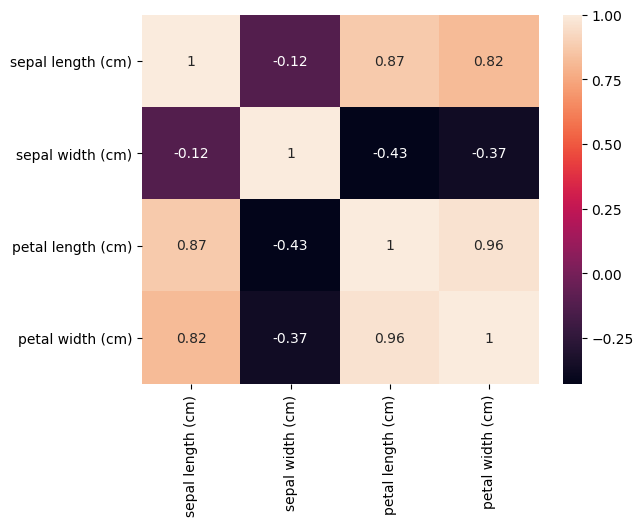

In [13]:
iris_corr = iris.drop(columns='class').corr(method='pearson')
sns.heatmap(
    iris_corr,
    xticklabels = iris_corr.columns,
    yticklabels = iris_corr.columns,
    annot = True
)
plt.show()